In [13]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ngeikerry/titanic/Titanic-Dataset.csv


In [14]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/ngeikerry/titanic/Titanic-Dataset.csv")
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [16]:
# 1. Fill Age with median (middle value)
df["Age"].fillna(df["Age"].median(), inplace=True)

# 2. Drop Cabin column (too many missing values)
df.drop(columns=["Cabin"], inplace=True)

# 3. Fill Embarked with most common value
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Confirm no more missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_55/548576789.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_55/548576789.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [17]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check outliers in Age and Fare
print("\nAge stats:")
print(df["Age"].describe())

print("\nFare stats:")
print(df["Fare"].describe())

Duplicate rows: 0

Age stats:
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

Fare stats:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [18]:
import numpy as np

# Cap Fare outliers at the 99th percentile
fare_cap = df["Fare"].quantile(0.99)
df["Fare"] = df["Fare"].clip(upper=fare_cap)

# Fix consistency - make sure Sex values are lowercase
df["Sex"] = df["Sex"].str.lower()

# Save cleaned dataset
df.to_csv("train_cleaned.csv", index=False)

print("Data cleaning complete!")
print("Fare now capped at:", round(fare_cap, 2))
print("Dataset shape:", df.shape)

Data cleaning complete!
Fare now capped at: 249.01
Dataset shape: (891, 11)


In [19]:
# 1. Family Size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 2. Is Alone
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# 3. Extract Title from Name
df["Title"] = df["Name"].str.extract(r',\s*([^\.]+)\.')
df["Title"] = df["Title"].str.strip()

# Simplify rare titles
df["Title"] = df["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"], "Rare"
)
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

print("Titles found:")
print(df["Title"].value_counts())

Titles found:
Title
Mr              517
Miss            185
Mrs             126
Master           40
Rare             22
the Countess      1
Name: count, dtype: int64


In [20]:
# Fix remaining rare titles
df["Title"] = df["Title"].replace("the Countess", "Rare")

print("Titles after fix:")
print(df["Title"].value_counts())

Titles after fix:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [21]:
# 4. Age Groups
def age_group(age):
    if age <= 12:
        return "Child"
    elif age <= 18:
        return "Teen"
    elif age <= 60:
        return "Adult"
    else:
        return "Senior"

df["AgeGroup"] = df["Age"].apply(age_group)

# 5. Fare per person
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

# 6. Deck from Cabin (already dropped, so mark all as Unknown)
df["Deck"] = "Unknown"

print("Age Groups:")
print(df["AgeGroup"].value_counts())
print("\nFare Per Person sample:")
print(df["FarePerPerson"].head())

Age Groups:
AgeGroup
Adult     730
Teen       70
Child      69
Senior     22
Name: count, dtype: int64

Fare Per Person sample:
0     3.62500
1    35.64165
2     7.92500
3    26.55000
4     8.05000
Name: FarePerPerson, dtype: float64


In [22]:
# One-hot encode Sex, Embarked, Title, AgeGroup
df = pd.get_dummies(df, columns=["Sex", "Embarked", "Title", "AgeGroup", "Deck"], drop_first=False)

# Ordinal encode Pclass (already a number, just confirm)
print("New columns added:")
print(df.columns.tolist())
print("\nDataset shape:", df.shape)

New columns added:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Adult', 'AgeGroup_Child', 'AgeGroup_Senior', 'AgeGroup_Teen', 'Deck_Unknown']

Dataset shape: (891, 27)


In [23]:
# Log transform skewed features
df["Fare_log"] = np.log1p(df["Fare"])
df["Age_log"] = np.log1p(df["Age"])

# Interaction features
df["Pclass_Fare"] = df["Pclass"] * df["Fare"]
df["Age_log"] = np.log1p(df["Age"])

print("Transformations done!")
print("\nFare_log sample:")
print(df["Fare_log"].head())

Transformations done!

Fare_log sample:
0    2.110213
1    4.280593
2    2.188856
3    3.990834
4    2.202765
Name: Fare_log, dtype: float64


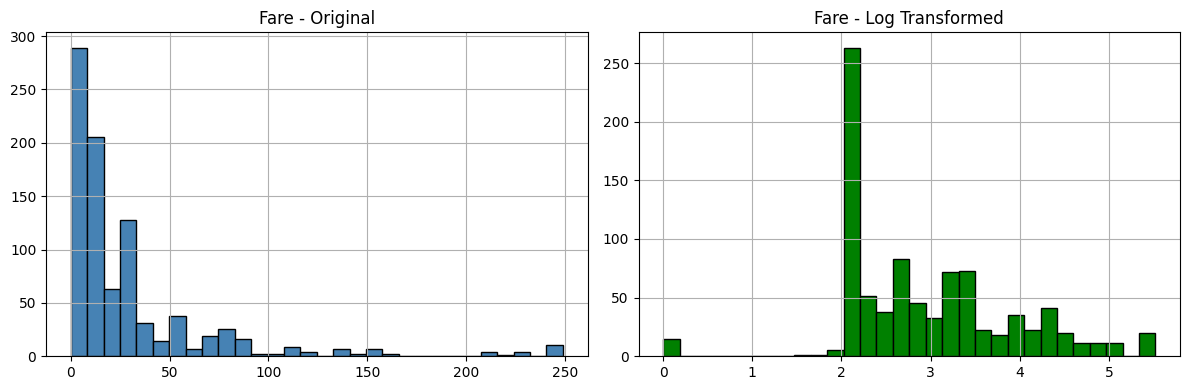

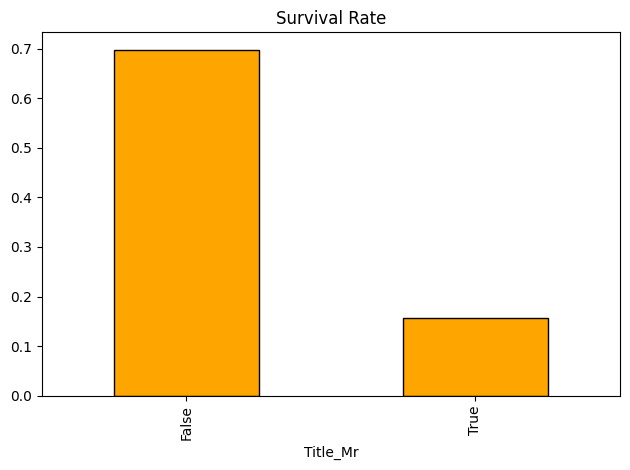

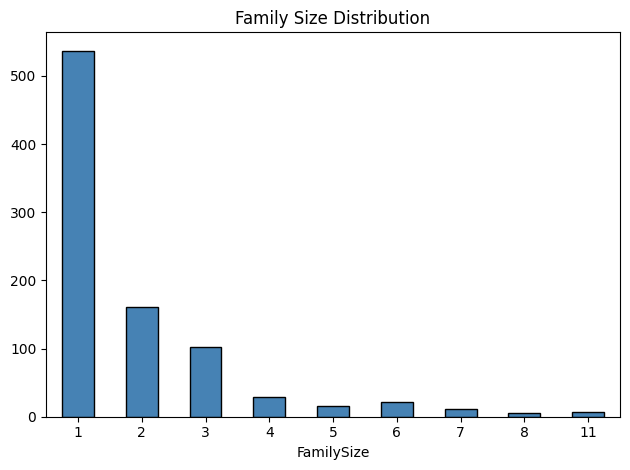

In [24]:
import matplotlib.pyplot as plt

# 1. Fare before and after log transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Fare"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Fare - Original")
df["Fare_log"].hist(bins=30, ax=axes[1], color="green", edgecolor="black")
axes[1].set_title("Fare - Log Transformed")
plt.tight_layout()
plt.show()

# 2. Survival by Title
df.groupby("Title_Mr")["Survived"].mean().plot(kind="bar", color="orange", edgecolor="black")
plt.title("Survival Rate")
plt.tight_layout()
plt.show()

# 3. Family Size distribution
df["FamilySize"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Family Size Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Select only numeric columns for model
features = df.drop(columns=["Survived", "Name", "Ticket", "PassengerId"])
features = features.select_dtypes(include=[float, int])

target = df["Survived"]

# Train a quick Random Forest to rank features
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(features, target)

# Show feature importance
importance = pd.Series(model.feature_importances_, index=features.columns)
importance = importance.sort_values(ascending=False)

print("Top features:")
print(importance.head(10))

Top features:
Age              0.183165
Age_log          0.178501
FarePerPerson    0.137197
Fare_log         0.133656
Fare             0.118577
Pclass_Fare      0.117005
Pclass           0.043915
FamilySize       0.033522
SibSp            0.025610
Parch            0.019032
dtype: float64


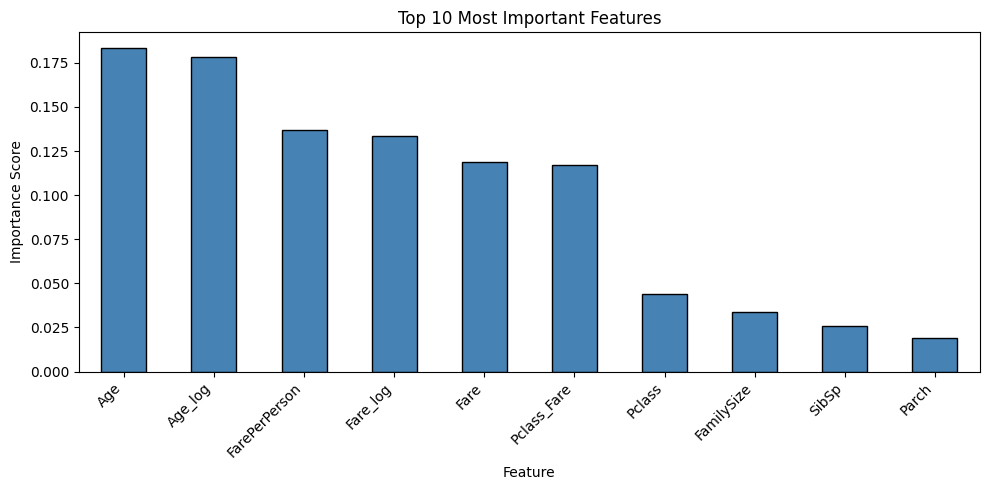


Selected features for model:
['Age', 'Age_log', 'FarePerPerson', 'Fare_log', 'Fare', 'Pclass_Fare', 'Pclass', 'FamilySize', 'SibSp', 'Parch']


In [26]:
# Plot feature importance
importance.head(10).plot(kind="bar", color="steelblue", edgecolor="black", figsize=(10,5))
plt.title("Top 10 Most Important Features")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Selected features (top 10)
selected_features = importance.head(10).index.tolist()
print("\nSelected features for model:")
print(selected_features)

In [27]:
# Save cleaned and engineered dataset
df.to_csv("train_cleaned.csv", index=False)
print("train_cleaned.csv saved successfully!")

train_cleaned.csv saved successfully!
